In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
from skimage import io,transform
from sklearn import preprocessing
import joblib
import cv2
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import PassiveAggressiveClassifier
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage.transform import resize
from skimage.io import imread

In [9]:
path = r"C:\Users\enjam\Downloads\Agricultural Sample code\Agricultural Sample code\Agricultural crops"
model_folder = r"model"
categories = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]
categories

['banana', 'Cherry', 'cotton', 'Lemon', 'maize', 'model', 'soyabean']

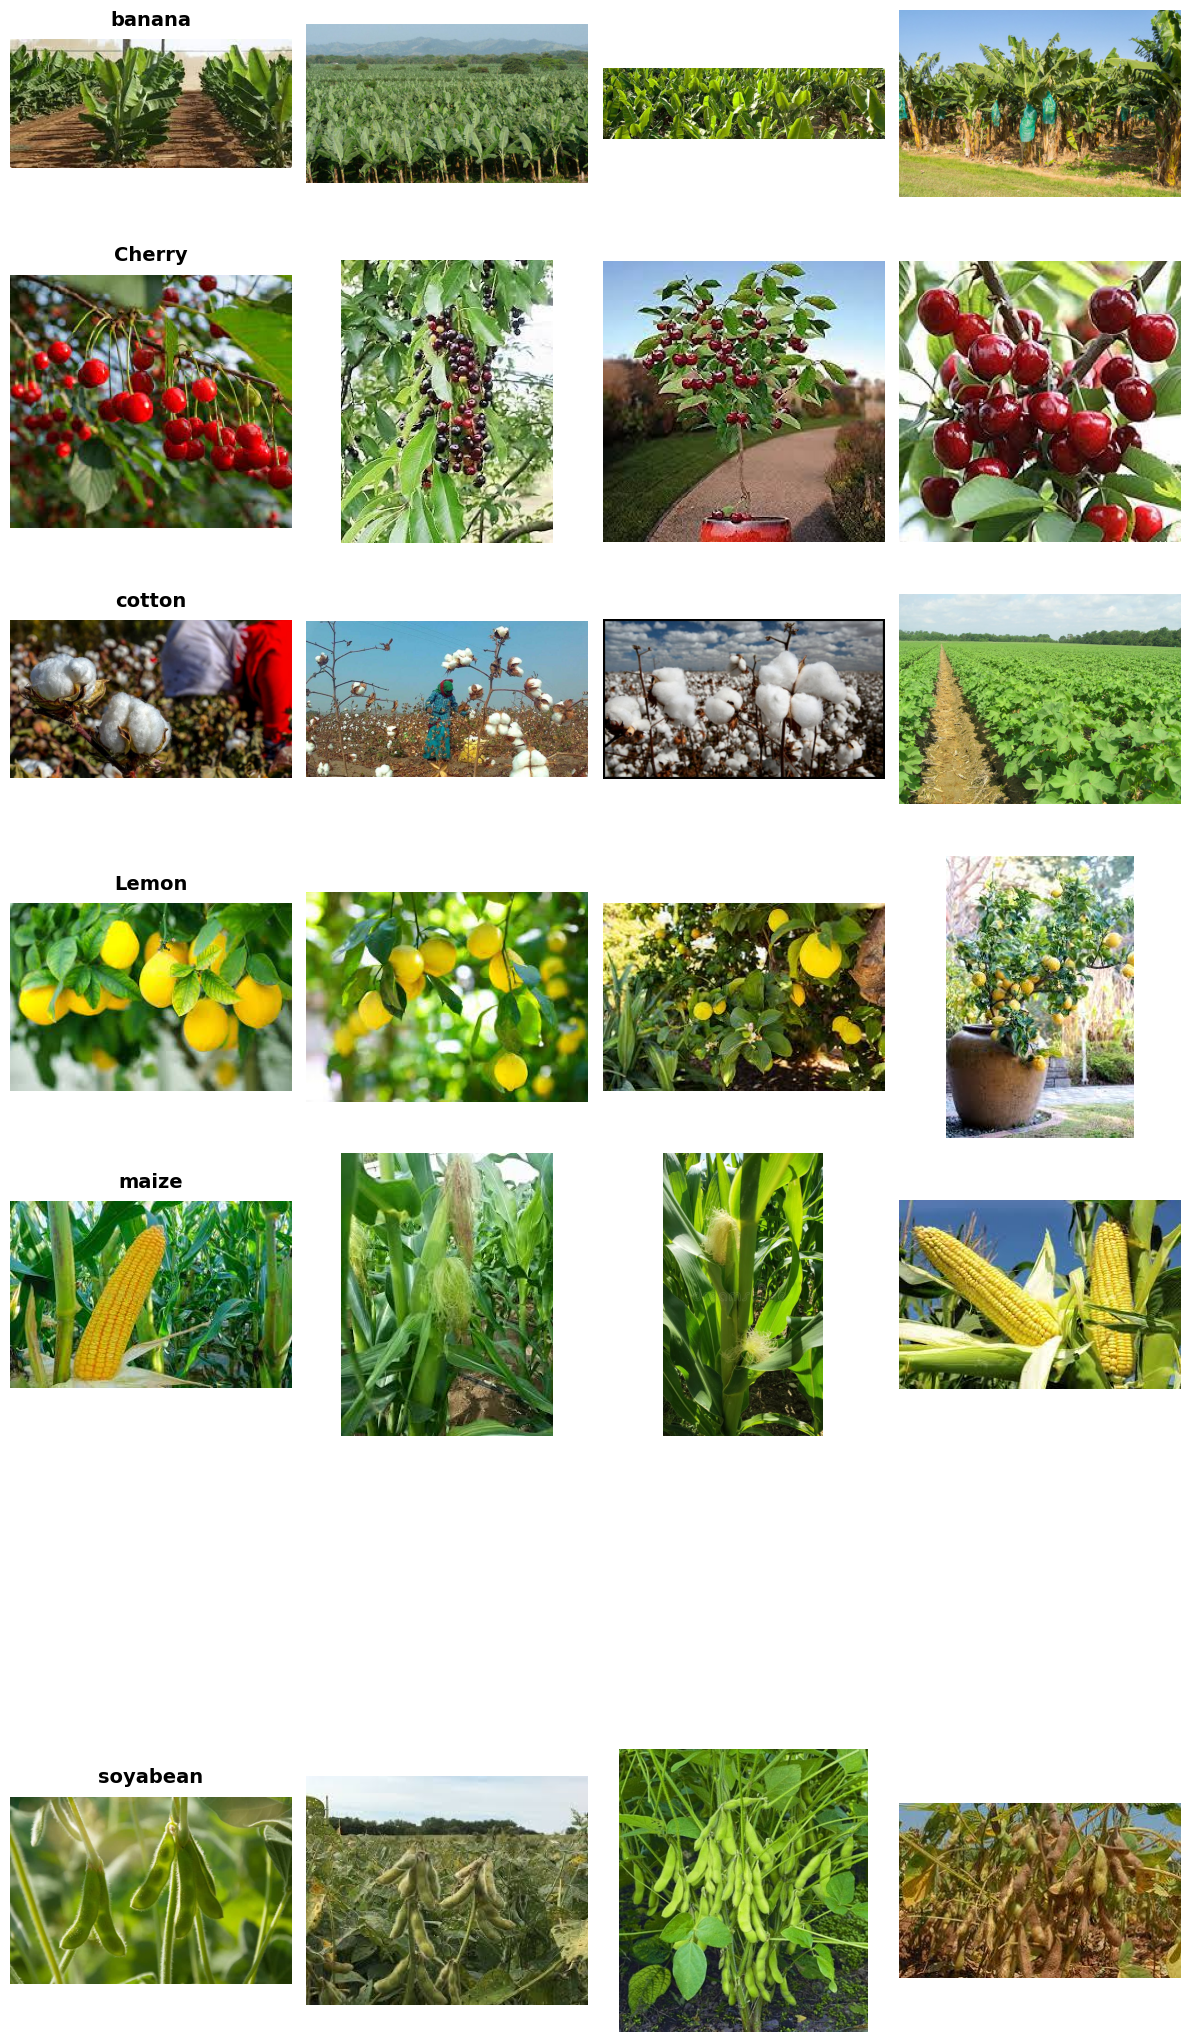

Final image saved at: results\classes_grid.png


In [10]:
num_classes = len(categories)
num_cols = 4  # 4 images per class

# Create results folder if it doesn't exist
results_folder = r"results"
os.makedirs(results_folder, exist_ok=True)

plt.figure(figsize=(num_cols * 3, num_classes * 3))

for i, category in enumerate(categories):
    folder_path = os.path.join(path, category)
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(("jpg", "jpeg", "png")) and 'Thumbs.db' not in f]
    
    selected_files = files[:4]  # pick 4 images per class
    
    for j, file in enumerate(selected_files):
        img_path = os.path.join(folder_path, file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR → RGB
        
        ax = plt.subplot(num_classes, num_cols, i * num_cols + j + 1)
        ax.imshow(img)
        ax.axis('off')
        
        # Add class name as a title above the first image of each row
        if j == 0:
            ax.set_title(category, fontsize=14, weight='bold', pad=10, loc='center')

plt.tight_layout()

# Save the final image
output_path = os.path.join(results_folder, "classes_grid.png")
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Final image saved at: {output_path}")

PREPROSSING

In [ ]:
model_folder = "model"
X_file = os.path.join(model_folder, "X_64x64.npy")  # Removed .txt (not needed)
Y_file = os.path.join(model_folder, "Y.npy")

if os.path.exists(X_file) and os.path.exists(Y_file):
    X = np.load(X_file)
    Y = np.load(Y_file)
    print(f"Loaded X shape: {X.shape}, Y shape: {Y.shape}")
else:
    print("Creating dataset...")
    X, Y = [], []
    
    for category_idx, category in enumerate(categories):
        category_path = os.path.join(path, category)
        files = [f for f in os.listdir(category_path) 
                if f.lower().endswith(('.jpg', '.jpeg', '.png')) 
                and 'thumbs.db' not in f.lower()]
        
        print(f"Loading {len(files)} images from {category}...")
        
        for file in files:
            img_path = os.path.join(category_path, file)
            img_array = cv2.imread(img_path)
            if img_array is not None:
                img_resized = resize(img_array, (64, 64, 3), anti_aliasing=True)
                X.append(img_resized.flatten())
                Y.append(category_idx)
    
    X = np.array(X)
    Y = np.array(Y)
    
    # CREATE FOLDER FIRST, then save
    os.makedirs(model_folder, exist_ok=True)
    np.save(X_file, X)
    np.save(Y_file, Y)
    print(f"Saved X shape: {X.shape}, Y shape: {Y.shape}")

Creating dataset...
Loading 62 images from banana...
Loading 64 images from Cherry...
Loading 64 images from cotton...
Loading 56 images from Lemon...
Loading 62 images from maize...
Loading 0 images from model...
Loading 60 images from soyabean...


In [12]:
df = pd.DataFrame(X)
df['Labels'] = Y
df
df.Labels.unique()

array([0, 1, 2, 3, 4, 6])

In [14]:
df = pd.DataFrame(X)
df['Labels'] = Y
df

,0,1,2,3,4,5,6,7,8,9,...,12279,12280,12281,12282,12283,12284,12285,12286,12287,Labels
0,0.822054,0.890191,0.898054,0.789271,0.853594,0.879271,0.887699,0.893814,0.910442,0.912653,...,0.074953,0.177780,0.195927,0.346207,0.444282,0.477441,0.462109,0.526740,0.573433,0
1,0.831936,0.763934,0.650419,0.833723,0.765820,0.652107,0.835078,0.767181,0.653456,0.834281,...,0.236805,0.410783,0.454221,0.299618,0.430781,0.529440,0.266507,0.394511,0.471779,0
2,0.096661,0.469993,0.373108,0.050697,0.539653,0.418160,0.051978,0.500248,0.388055,0.064909,...,0.067498,0.311047,0.240690,0.084904,0.219176,0.183010,0.154463,0.245174,0.203283,0
3,0.900703,0.698304,0.516338,0.900927,0.698488,0.516210,0.902208,0.699585,0.517523,0.903566,...,0.232862,0.660601,0.608008,0.215427,0.604164,0.528452,0.241133,0.627729,0.556886,0
4,0.914360,0.931915,0.907989,0.451820,0.609907,0.473369,0.275868,0.577561,0.473584,0.232012,...,0.341884,0.408893,0.495220,0.401941,0.486979,0.536294,0.437748,0.539248,0.584582,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363,0.991622,0.972033,0.875694,0.994741,0.972741,0.876595,0.995132,0.960018,0.864569,0.878187,...,0.026112,0.132577,0.061561,0.191064,0.554408,0.447396,0.083186,0.268117,0.216761,6
364,0.979537,0.947324,0.919873,0.998796,0.970111,0.942660,0.993481,0.962643,0.935192,0.999710,...,0.208877,0.452291,0.329685,0.214236,0.482122,0.346713,0.223119,0.490409,0.357650,6
365,0.096893,0.339874,0.244379,0.124122,0.362934,0.269218,0.156426,0.392177,0.298338,0.191833,...,0.189782,0.374537,0.350241,0.099515,0.266849,0.281497,0.082537,0.236823,0.288420,6
366,0.100986,0.339930,0.249101,0.120139,0.369706,0.276224,0.134338,0.392787,0.300115,0.163995,...,0.187434,0.379915,0.333526,0.102466,0.269989,0.269414,0.077638,0.237723,0.283144,6


In [15]:
Y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,

In [16]:
df.Labels.unique()

array([0, 1, 2, 3, 4, 6])

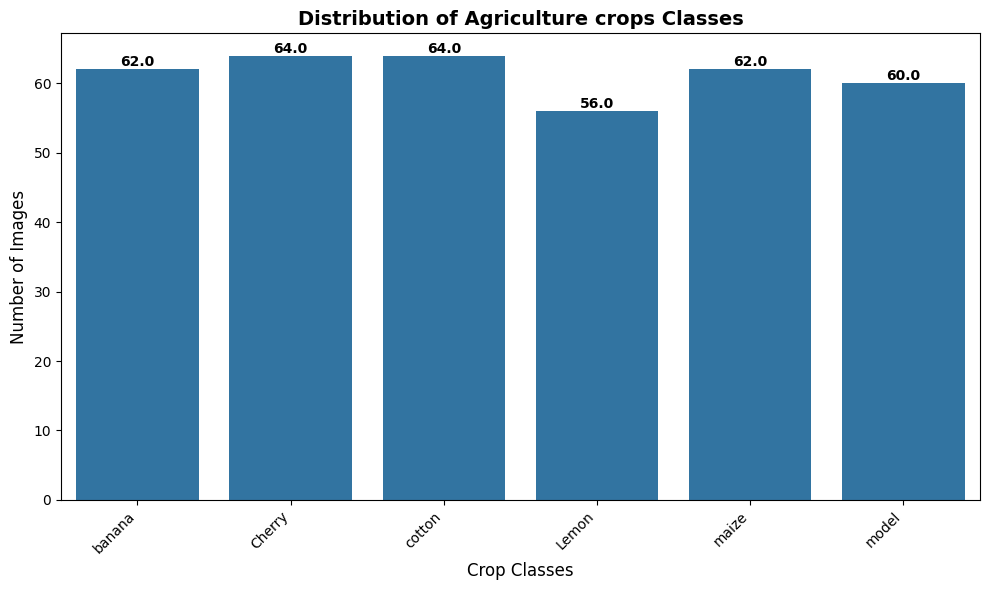

In [17]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=Y)

# Replace x-ticks with class names automatically
ax.set_xticklabels(categories, rotation=45, ha='right')

# Add value labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xlabel("Crop Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Distribution of Agriculture crops Classes", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## data splitting

In [18]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split the data
x_train, x_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=77, stratify=Y
)

# Apply SMOTE on training data only
sm = SMOTE()
x_train, y_train = sm.fit_resample(x_train, y_train)

print("After SMOTE:")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

After SMOTE:
x_train: (306, 12288)
y_train: (306,)


# Function to Calculate Metrics

In [19]:

# ──────────────────────────────────────────────────────────────
# Global containers
# ──────────────────────────────────────────────────────────────
metrics_overall = []                    # Overall metrics
class_metrics_storage = {}              # Key = class name → list of dicts (one per model)
categories=['banana', 'Cherry', 'cotton', 'Lemon', 'maize', 'soyabean']
def calculateMetrics(algorithm, predict, testY):
    """
    Call this for every model (RFC, DTC, NBC, etc.)
    """
    testY = testY.astype('int')
    predict = predict.astype('int')
    
    # ── Overall metrics ─────────────────────────────────────
    acc  = accuracy_score(testY, predict) * 100
    prec = precision_score(testY, predict, average='macro', zero_division=0) * 100
    rec  = recall_score(testY, predict, average='macro', zero_division=0) * 100
    f1   = f1_score(testY, predict, average='macro', zero_division=0) * 100
    
    metrics_overall.append({
        'Model': algorithm,
        'Accuracy':  round(acc, 2),
        'Precision': round(prec, 2),
        'Recall':    round(rec, 2),
        'F1-Score':  round(f1, 2)
    })
    
    print(f"\n=== {algorithm} Overall ===")
    print(f"Accuracy  : {acc:.2f}%")
    print(f"Precision : {prec:.2f}%")
    print(f"Recall    : {rec:.2f}%")
    print(f"F1-Score  : {f1:.2f}%\n")
    
    # ── Class-wise metrics ──────────────────────────────────
    report = classification_report(testY, predict, target_names=categories,
                                  output_dict=True, zero_division=0)
    print("\n=== Classification Report ===")
    print(classification_report(testY, predict, target_names=categories, zero_division=0))

    for cls in categories:
        # Initialize list for this class if first time
        if cls not in class_metrics_storage:
            class_metrics_storage[cls] = []
        
        class_metrics_storage[cls].append({
            'Model':     algorithm,
            'Precision': round(report[cls]['precision'] * 100, 2),
            'Recall':    round(report[cls]['recall'] * 100, 2),
            'F1-Score':  round(report[cls]['f1-score'] * 100, 2)
        })
    
    # ── Confusion matrix ────────────────────────────────────
    cm = confusion_matrix(testY, predict)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=categories, yticklabels=categories, cbar=False)
    plt.title(f"{algorithm} - Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## model building and training

## balanced randam forest


=== Balanced Random Forest Overall ===
Accuracy  : 91.89%
Precision : 92.18%
Recall    : 91.63%
F1-Score  : 91.70%


=== Classification Report ===
              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        12
      Cherry       0.85      0.85      0.85        13
      cotton       1.00      1.00      1.00        13
       Lemon       0.82      0.82      0.82        11
       maize       0.87      1.00      0.93        13
    soyabean       1.00      0.83      0.91        12

    accuracy                           0.92        74
   macro avg       0.92      0.92      0.92        74
weighted avg       0.92      0.92      0.92        74



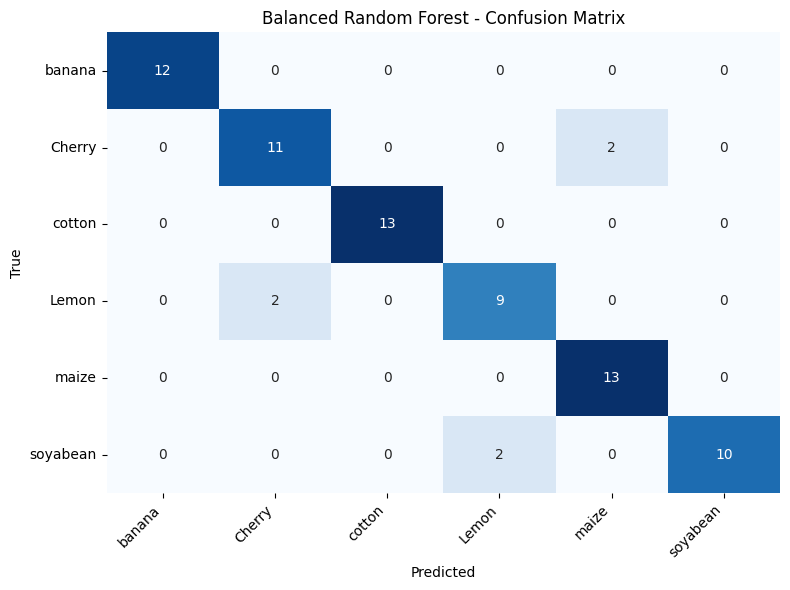

In [21]:
model_path = r"model\balanced_random_forest.pkl"

os.makedirs(os.path.dirname(model_path), exist_ok=True)

if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    balanced_random_forest = joblib.load(model_path)
    predict = balanced_random_forest.predict(x_test)
    calculateMetrics("Balanced Random Forest", predict, y_test)

else:
    balanced_random_forest = BalancedRandomForestClassifier()
    balanced_random_forest.fit(x_train, y_train)
    predict = balanced_random_forest.predict(x_test)
    joblib.dump(balanced_random_forest, model_path)
    calculateMetrics("Balanced Random Forest", predict, y_test)



=== LDA Classifier Overall ===
Accuracy  : 72.97%
Precision : 76.16%
Recall    : 72.45%
F1-Score  : 73.32%


=== Classification Report ===
              precision    recall  f1-score   support

      banana       0.82      0.75      0.78        12
      Cherry       0.65      0.85      0.73        13
      cotton       1.00      0.85      0.92        13
       Lemon       0.46      0.55      0.50        11
       maize       0.64      0.69      0.67        13
    soyabean       1.00      0.67      0.80        12

    accuracy                           0.73        74
   macro avg       0.76      0.72      0.73        74
weighted avg       0.77      0.73      0.74        74



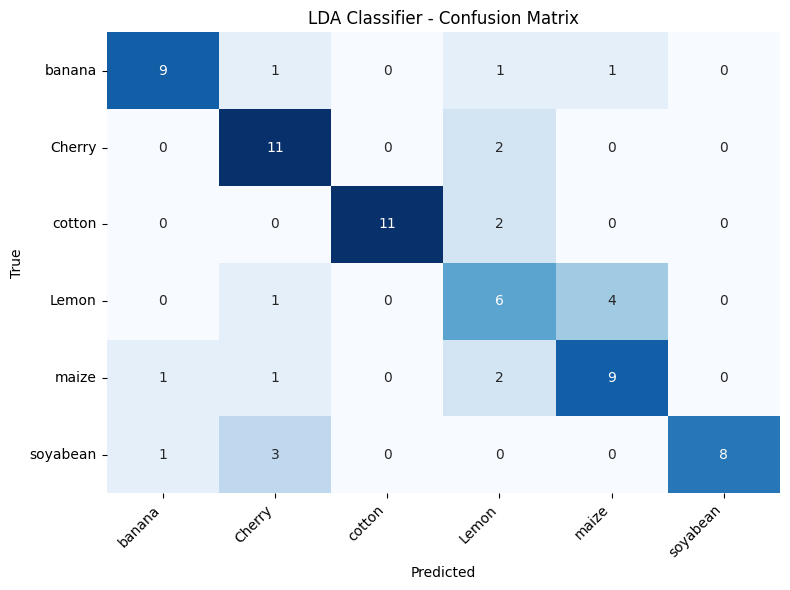

In [22]:

import joblib
import os

model_path = r"model\lda_classifier.pkl"

# Ensure folder exists before saving
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Load or train LDA Classifier model
if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    lda_clf = joblib.load(model_path)
    predict = lda_clf.predict(x_test)
    calculateMetrics("LDA Classifier", predict, y_test)
else:
    lda_clf = LinearDiscriminantAnalysis()
    lda_clf.fit(x_train, y_train)
    joblib.dump(lda_clf, model_path)

    predict = lda_clf.predict(x_test)
    calculateMetrics("LDA Classifier", predict, y_test)



=== AdaBoost Classifier Overall ===
Accuracy  : 62.16%
Precision : 80.91%
Recall    : 62.17%
F1-Score  : 64.91%


=== Classification Report ===
              precision    recall  f1-score   support

      banana       0.29      0.83      0.43        12
      Cherry       1.00      0.54      0.70        13
      cotton       0.91      0.77      0.83        13
       Lemon       0.83      0.45      0.59        11
       maize       1.00      0.38      0.56        13
    soyabean       0.82      0.75      0.78        12

    accuracy                           0.62        74
   macro avg       0.81      0.62      0.65        74
weighted avg       0.82      0.62      0.65        74



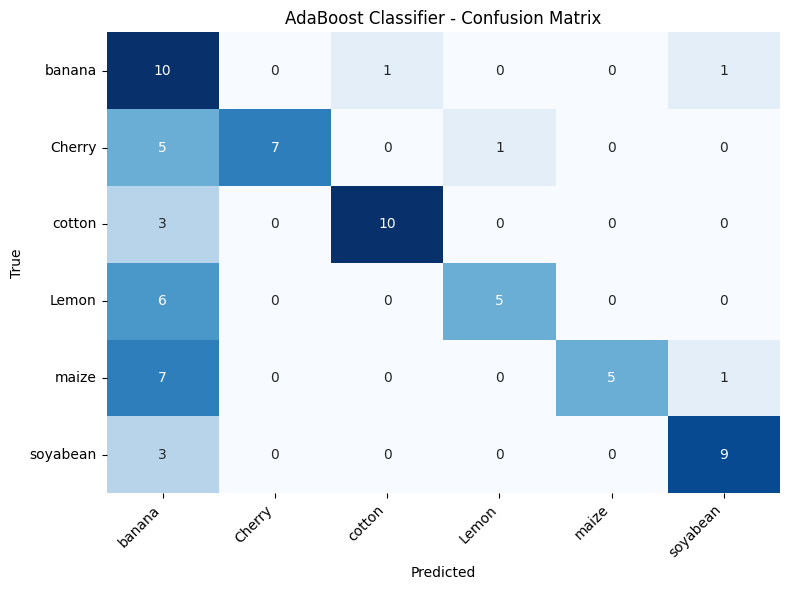

In [23]:
from sklearn.ensemble import AdaBoostClassifier
import joblib
import os

model_path = r"model\adaboost_classifier.pkl"

# Ensure folder exists before saving
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Load or train AdaBoost Classifier model
if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    ada_clf = joblib.load(model_path)
    predict = ada_clf.predict(x_test)
    calculateMetrics("AdaBoost Classifier", predict, y_test)
else:
    ada_clf = AdaBoostClassifier()
    ada_clf.fit(x_train, y_train)
    joblib.dump(ada_clf, model_path)

    predict = ada_clf.predict(x_test)
    calculateMetrics("AdaBoost Classifier", predict, y_test)



=== SVM Classifier Overall ===
Accuracy  : 91.89%
Precision : 93.17%
Recall    : 91.38%
F1-Score  : 91.44%


=== Classification Report ===
              precision    recall  f1-score   support

      banana       0.86      1.00      0.92        12
      Cherry       0.73      0.85      0.79        13
      cotton       1.00      1.00      1.00        13
       Lemon       1.00      0.64      0.78        11
       maize       1.00      1.00      1.00        13
    soyabean       1.00      1.00      1.00        12

    accuracy                           0.92        74
   macro avg       0.93      0.91      0.91        74
weighted avg       0.93      0.92      0.92        74



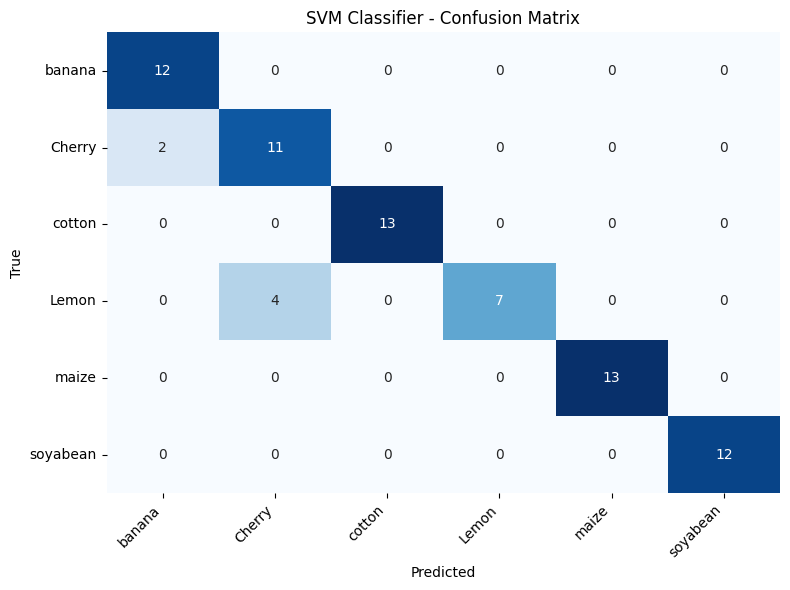

In [24]:

import joblib
import os

model_path = r"model\svm_classifier.pkl"

# Ensure folder exists before saving
os.makedirs(os.path.dirname(model_path), exist_ok=True)

# Load or train SVM Classifier model
if os.path.exists(model_path) and os.path.getsize(model_path) > 0:
    svm_clf = joblib.load(model_path)
    predict = svm_clf.predict(x_test)
    calculateMetrics("SVM Classifier", predict, y_test)
else:
    svm_clf = SVC()
    svm_clf.fit(x_train, y_train)
    joblib.dump(svm_clf, model_path)

    predict = svm_clf.predict(x_test)
    calculateMetrics("SVM Classifier", predict, y_test)


In [25]:
def create_per_class_dataframes():
    if not metrics_overall:
        print("No models evaluated yet!")
        return None

    overall_df = pd.DataFrame(metrics_overall)
    overall_df = overall_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
    
    print("\n" + "="*60)
    print("OVERALL MODEL COMPARISON")
    print("="*60)
    print(overall_df.round(4))
    print()

    class_dfs = {}
    for cls, records in class_metrics_storage.items():
        df = pd.DataFrame(records)
        df = df.set_index('Model')[['Precision', 'Recall', 'F1-Score']]
        
        var_name = cls.replace(" ", "_").replace("-", "_") + "_df"
        globals()[var_name] = df
        class_dfs[cls] = df   # key by original class name (more readable)

        print(f"{cls.upper()} CLASS PERFORMANCE".center(60))
        print("-" * 60)
        print(df.round(4))
        print()

    return overall_df, class_dfs
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 7)

def plot_overall_with_values():
    ax = overall_df.plot(kind='bar', width=0.8, edgecolor='black', alpha=0.9)
    plt.title('Overall Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Score (%)')
    plt.xlabel('Model')
    plt.ylim(0, 105)
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)

    # Add values on top of bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()


def plot_per_class_metric_universal(metric_name):
    # Reconstruct correct class names from the original storage (universal!)
    class_names = list(class_metrics_storage.keys())  # e.g., ['Cirriform Clouds', 'Clear Sky', ...]
    
    # Build DataFrame: rows = models, columns = clean class names
    data = pd.DataFrame()
    for cls in class_names:
        records = class_metrics_storage[cls]
        df = pd.DataFrame(records).set_index('Model')
        data[cls] = df[metric_name]

    # Ensure same model order as overall_df
    data = data.loc[overall_df.index]

    # Plot
    plt.figure()
    ax = data.plot(kind='bar', width=0.82, edgecolor='black', alpha=0.9)
    
    plt.title(f'{metric_name} per Cloud Class', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel(f'{metric_name} (%)')
    plt.xlabel('Model')
    plt.ylim(0, 105)
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Cloud Class', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.grid(axis='y', alpha=0.3)

    # Add value labels on top of every bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=9.5, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [26]:
 overall_df, class_dfs = create_per_class_dataframes()


OVERALL MODEL COMPARISON
                        Accuracy  Precision  Recall  F1-Score
Model                                                        
Balanced Random Forest     91.89      92.18   91.63     91.70
LDA Classifier             72.97      76.16   72.45     73.32
AdaBoost Classifier        62.16      80.91   62.17     64.91
SVM Classifier             91.89      93.17   91.38     91.44

                  BANANA CLASS PERFORMANCE                  
------------------------------------------------------------
                        Precision  Recall  F1-Score
Model                                              
Balanced Random Forest     100.00  100.00    100.00
LDA Classifier              81.82   75.00     78.26
AdaBoost Classifier         29.41   83.33     43.48
SVM Classifier              85.71  100.00     92.31

                  CHERRY CLASS PERFORMANCE                  
------------------------------------------------------------
                        Precision  Recall  F

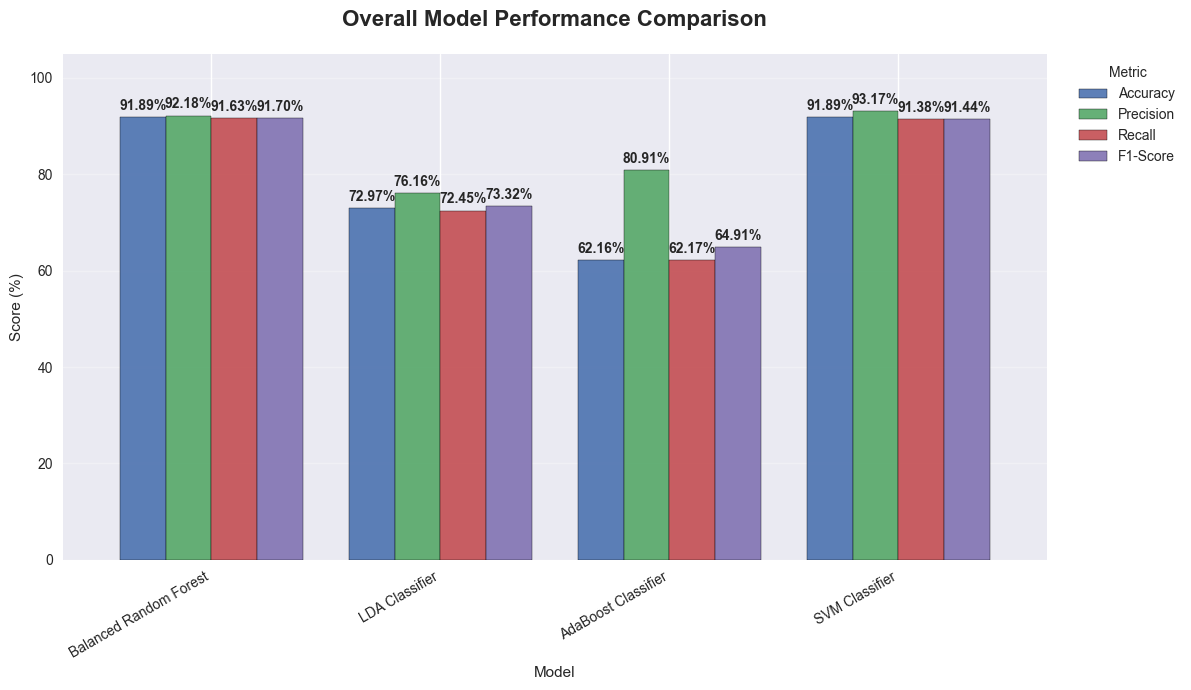

In [27]:
plot_overall_with_values()

<Figure size 1200x700 with 0 Axes>

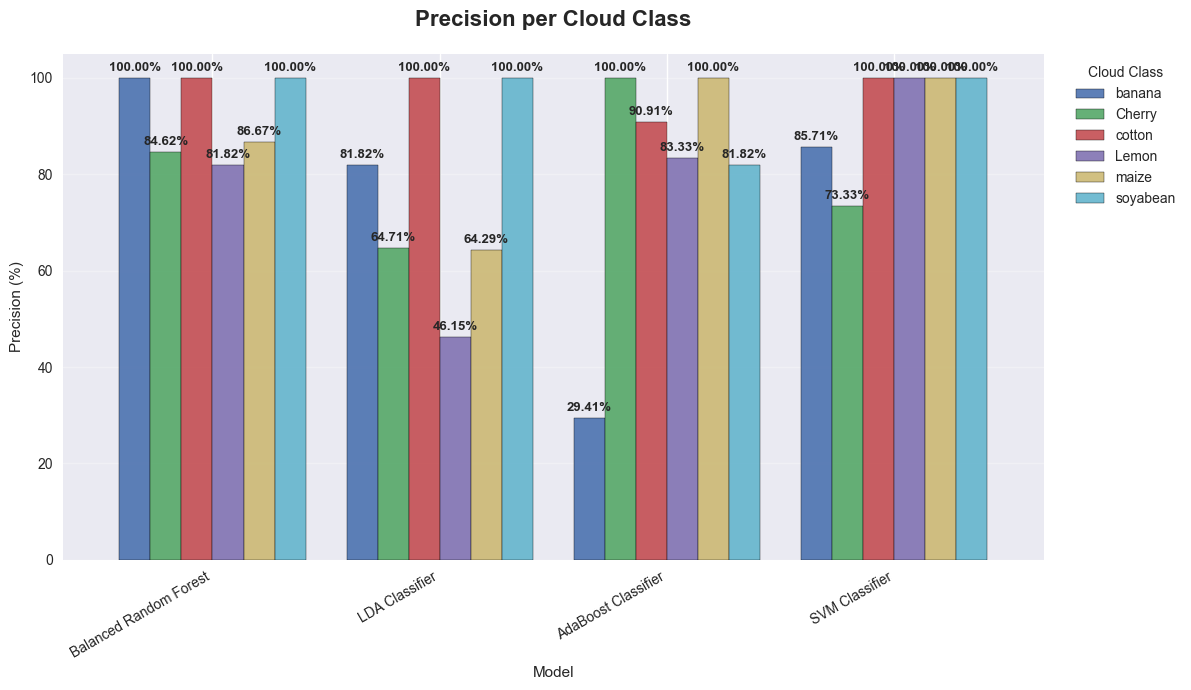

In [28]:
plot_per_class_metric_universal('Precision')

<Figure size 1200x700 with 0 Axes>

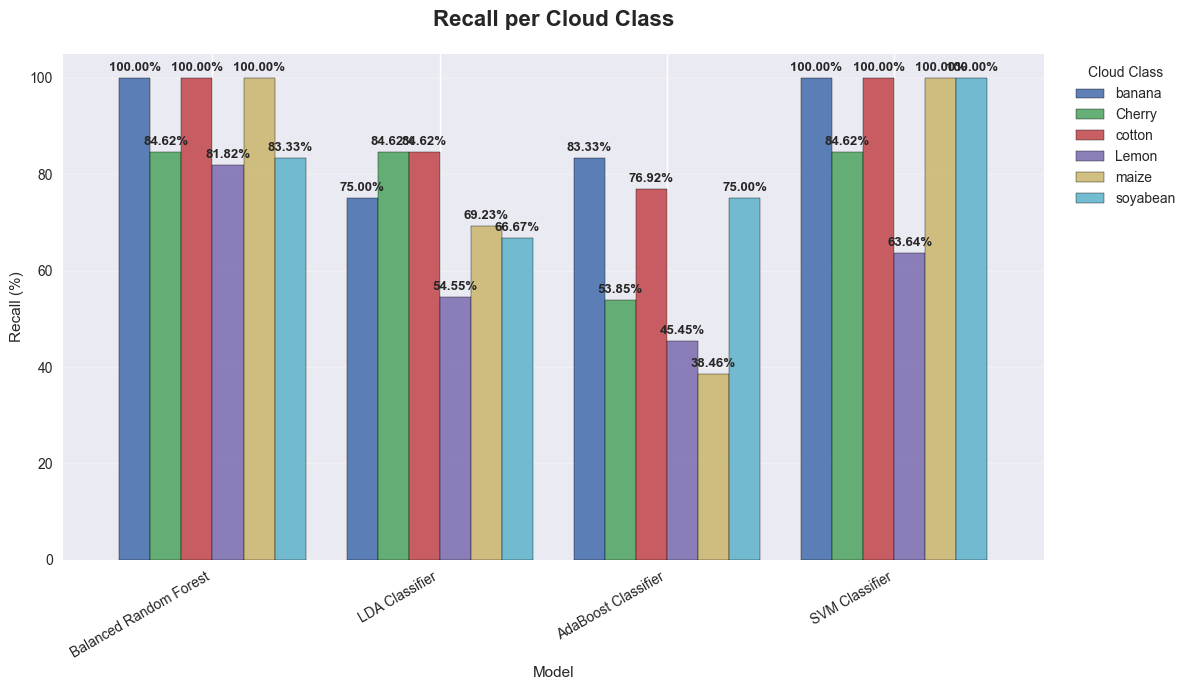

In [29]:
plot_per_class_metric_universal('Recall')

<Figure size 1200x700 with 0 Axes>

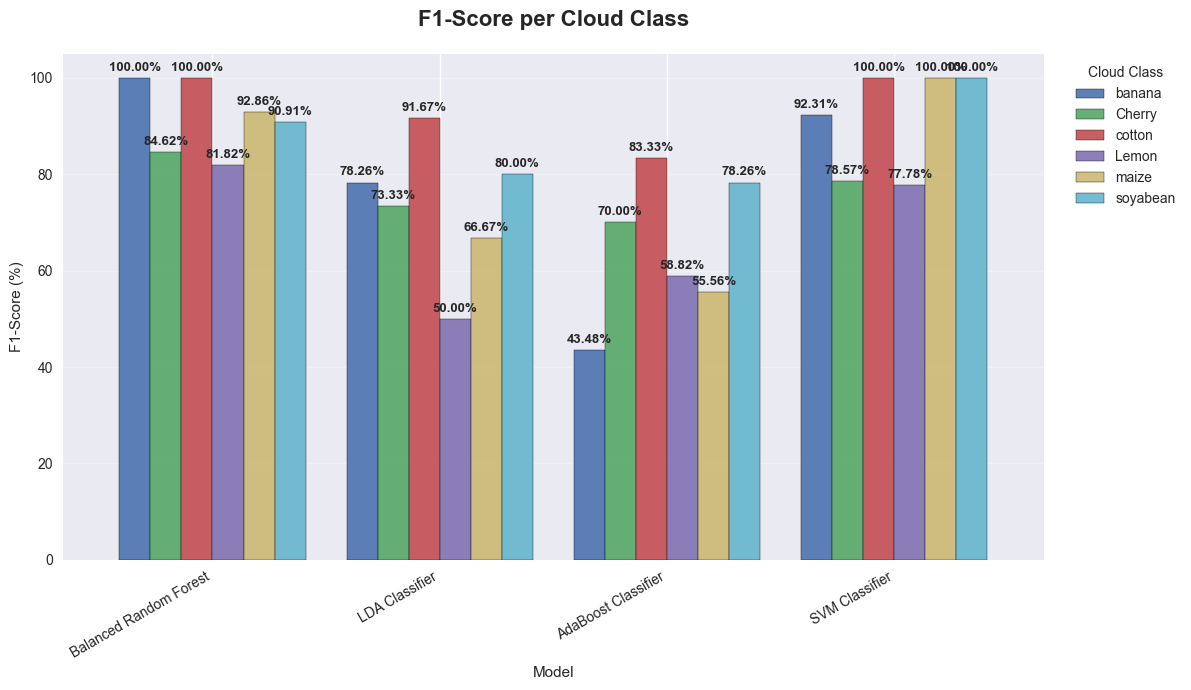

In [30]:
plot_per_class_metric_universal('F1-Score')

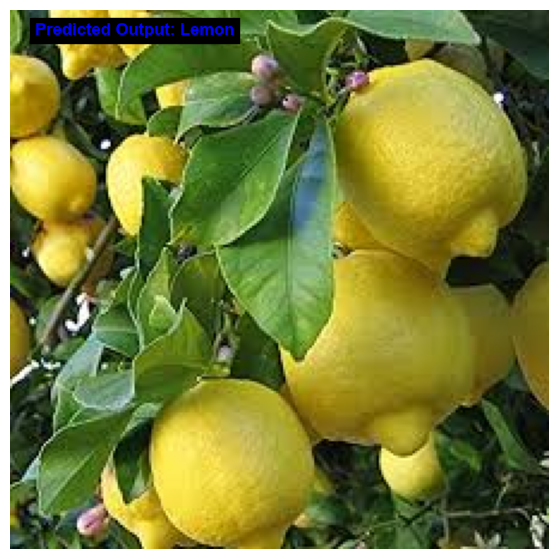

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.svm import SVC
SVC_Classifier = joblib.load(r"model\svm_classifier.pkl")

# ------------------------------
# FIX: DEFINE CATEGORIES
# ------------------------------
categories=['banana', 'Cherry', 'cotton', 'Lemon', 'maize', 'soyabean']
def predict_image(image_path):
    img = load_img(image_path, target_size=(64, 64))
    img_array = img_to_array(img)
    img_array = img_array / 255.0
    img_array = img_array.flatten()
    img_array = np.expand_dims(img_array, axis=0)

    predicted_class = SVC_Classifier.predict(img_array)[0]
    return predicted_class

image_path = r"C:\Users\enjam\Downloads\Agricultural Sample code\Agricultural Sample code\Agricultural crops\model\Lemon - Copy\images10.jpg"
output_number = predict_image(image_path)
output_name = categories[output_number]

img = load_img(image_path)
plt.imshow(img)
plt.text(10, 10, f'Predicted Output: {output_name}', color='blue', fontsize=12, weight='bold', backgroundcolor='black')
plt.axis('off')
plt.show()
